IMPORT LIBRARIES

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

DOWNLOAD DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("programmerrdai/road-issues-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-issues-detection-dataset' dataset.
Path to dataset files: /kaggle/input/road-issues-detection-dataset


In [ ]:
import os
!ls "$path"

data


In [ ]:
data_dir = os.path.join(path, "data")
print(data_dir)

/kaggle/input/road-issues-detection-dataset/data


In [ ]:
!ls "$data_dir"

'Public Cleanliness + Environmental Issues'  'Road Issues'


In [ ]:
road_issues_dir = os.path.join(data_dir, "Road Issues")
print(road_issues_dir)

/kaggle/input/road-issues-detection-dataset/data/Road Issues


In [ ]:
!ls "$road_issues_dir"

'Broken Road Sign Issues'  'Illegal Parking Issues'  'Pothole Issues'
'Damaged Road issues'	   'Mixed Issues'


In [ ]:
import os

base_path = "/kaggle/input/road-issues-detection-dataset/data/Road Issues"
for folder in os.listdir(base_path):
    print(folder, "→", len(os.listdir(os.path.join(base_path, folder))), "images")

Mixed Issues → 191 images
Damaged Road issues → 677 images
Illegal Parking Issues → 104 images
Broken Road Sign Issues → 1793 images
Pothole Issues → 3348 images


DATA AUGMENTATION

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    road_issues_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    road_issues_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4893 images belonging to 5 classes.
Found 1220 images belonging to 5 classes.


BUILD AND FINE TUNE THE MODEL

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze most layers
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_data.num_classes, activation='softmax')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,307,793 (127.06 MB)

 Trainable params: 4,728,581 (18.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

 Optimizer params: 9,457,164 (36.08 MB)

TRAIN THE MODEL

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_road_model.h5', monitor='val_accuracy', save_best_only=True)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8278 - loss: 0.5423

153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 521ms/step - accuracy: 0.8278 - loss: 0.5423 - val_accuracy: 0.6984 - val_loss: 0.7694
Epoch 2/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8337 - loss: 0.5199

153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 520ms/step - accuracy: 0.8337 - loss: 0.5199 - val_accuracy: 0.7484 - val_loss: 0.6638
Epoch 3/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8330 - loss: 0.5158

153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 522ms/step - accuracy: 0.8330 - loss: 0.5158 - val_accuracy: 0.7885 - val_loss: 0.6031
Epoch 4/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.8391 - loss: 0.5044

153/153 ━━━━━━━━━━━━━━━━━━━━ 82s 538ms/step - accuracy: 0.8391 - loss: 0.5045 - val_accuracy: 0.8328 - val_loss: 0.7913
Epoch 5/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 79s 515ms/step - accuracy: 0.8425 - loss: 0.5194 - val_accuracy: 0.8082 - val_loss: 0.6483
Epoch 6/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 79s 517ms/step - accuracy: 0.8493 - loss: 0.4811 - val_accuracy: 0.5402 - val_loss: 2.1742
Epoch 7/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 524ms/step - accuracy: 0.8539 - loss: 0.4807 - val_accuracy: 0.8148 - val_loss: 0.5262
Epoch 8/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 81s 527ms/step - accuracy: 0.8545 - loss: 0.4771 - val_accuracy: 0.7746 - val_loss: 0.7239
Epoch 9/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8531 - loss: 0.4931

153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 521ms/step - accuracy: 0.8531 - loss: 0.4930 - val_accuracy: 0.8393 - val_loss: 0.5339
Epoch 10/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 518ms/step - accuracy: 0.8581 - loss: 0.4588 - val_accuracy: 0.7295 - val_loss: 0.6854
Epoch 11/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 524ms/step - accuracy: 0.8580 - loss: 0.4509 - val_accuracy: 0.6467 - val_loss: 1.2352
Epoch 12/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 81s 526ms/step - accuracy: 0.8464 - loss: 0.4654 - val_accuracy: 0.8000 - val_loss: 0.7176
Epoch 13/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8515 - loss: 0.4523

153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 525ms/step - accuracy: 0.8515 - loss: 0.4523 - val_accuracy: 0.8459 - val_loss: 0.4650
Epoch 14/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 81s 528ms/step - accuracy: 0.8606 - loss: 0.4333 - val_accuracy: 0.8336 - val_loss: 0.6402
Epoch 15/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 523ms/step - accuracy: 0.8614 - loss: 0.4564 - val_accuracy: 0.7902 - val_loss: 0.5965
Epoch 16/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 79s 518ms/step - accuracy: 0.8485 - loss: 0.4641 - val_accuracy: 0.3598 - val_loss: 2.6630
Epoch 17/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 80s 521ms/step - accuracy: 0.8557 - loss: 0.4449 - val_accuracy: 0.7123 - val_loss: 1.0883
Epoch 18/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 81s 529ms/step - accuracy: 0.8548 - loss: 0.4480 - val_accuracy: 0.8205 - val_loss: 0.6224


EVALUATE THE BEST MODEL

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_road_model.h5')
val_loss, val_acc = best_model.evaluate(val_data)
print(f"\n✅ Best Validation Accuracy: {val_acc:.2f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.8452 - loss: 0.4701

✅ Best Validation Accuracy: 0.85


PREDICTION

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


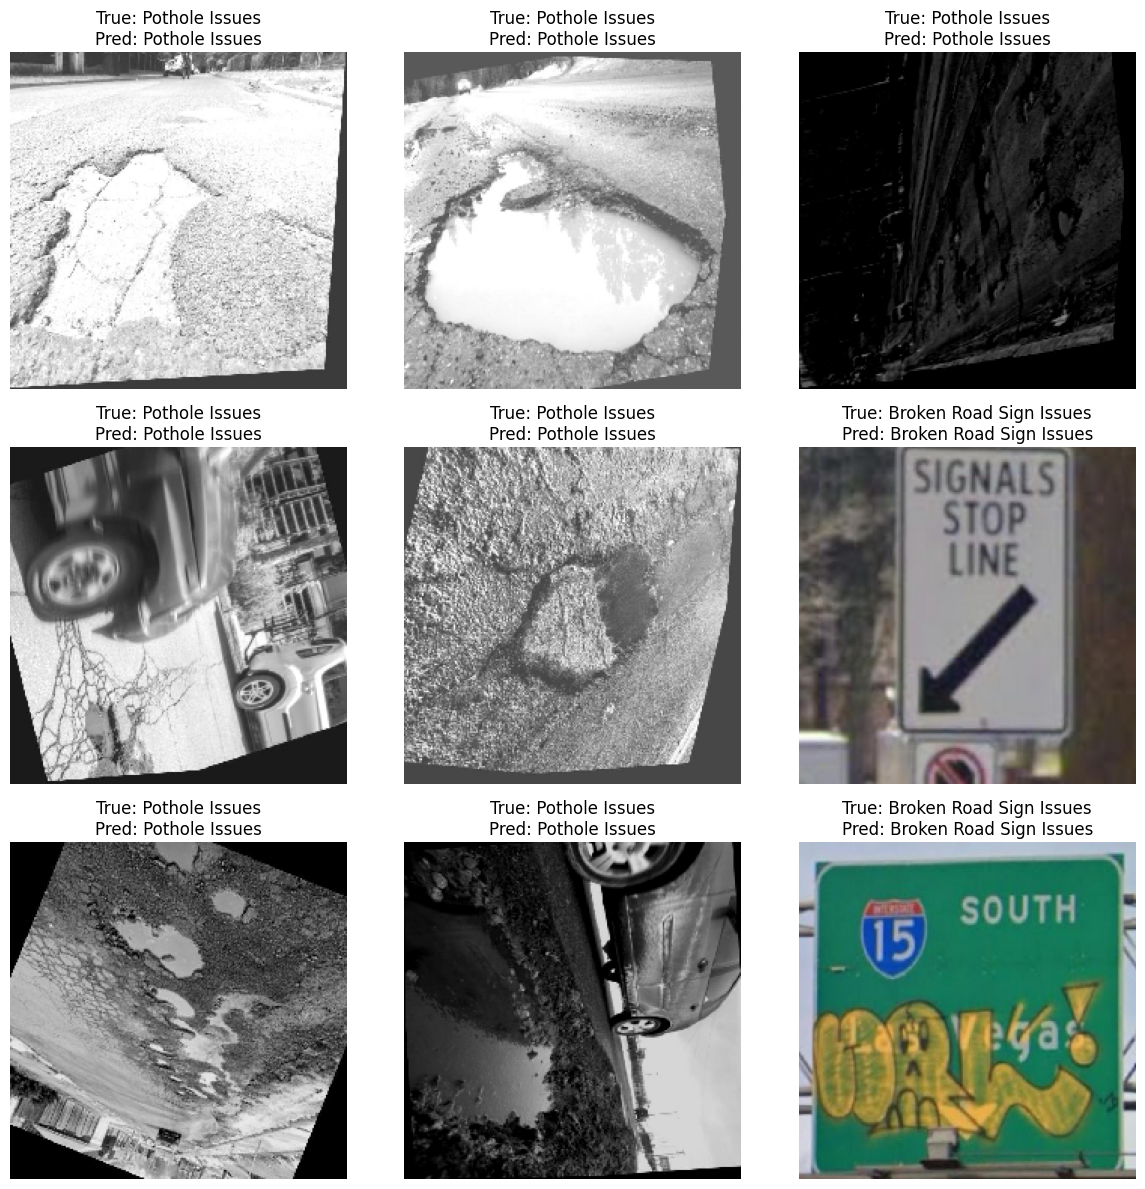

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get class labels
class_labels = list(train_data.class_indices.keys())

# Pick a few random images from the validation set
x, y = next(val_data)

plt.figure(figsize=(12, 12))
for i in range(9):  # show 9 images
    img = x[i]
    true_label = class_labels[np.argmax(y[i])]
    pred_label = class_labels[np.argmax(model.predict(img[np.newaxis, ...]))]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
plt.tight_layout()
plt.show()

ACCURACY PLOT

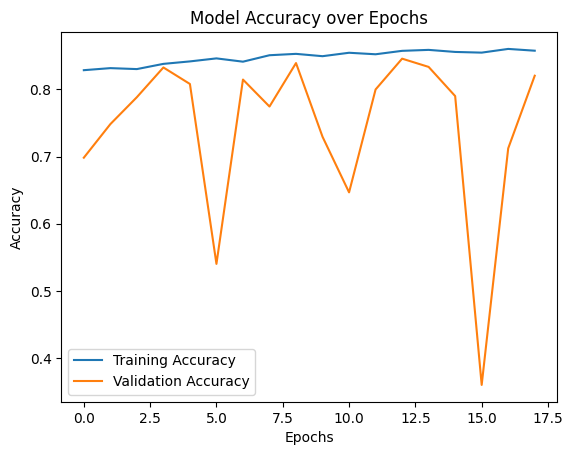

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy over Epochs')
plt.show()

LOSS PLOT

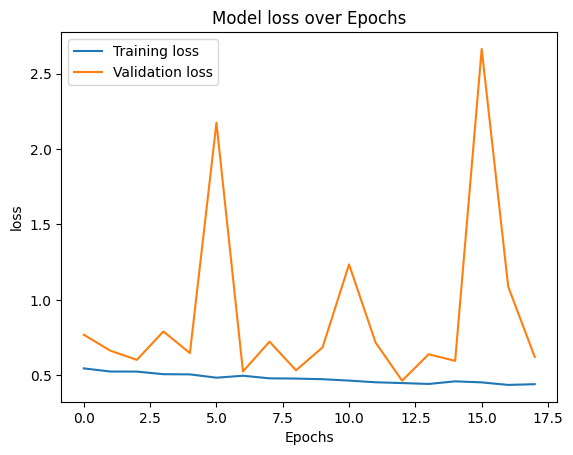

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.title('Model loss over Epochs')
plt.show()

In [ ]:
# Save the trained model
model.save("/content/road_damage_model.h5")
print("✅ Model saved successfully as road_damage_model.h5")

✅ Model saved successfully as road_damage_model.h5


In [ ]:
!ls /content/

best_road_model.h5  road_damage_model.h5  sample_data


In [ ]:
#RELOAD THE MODEL
from tensorflow.keras.models import load_model

# Load your saved model
model = load_model("/content/road_damage_model.h5")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
from google.colab import files
files.download("/content/road_damage_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


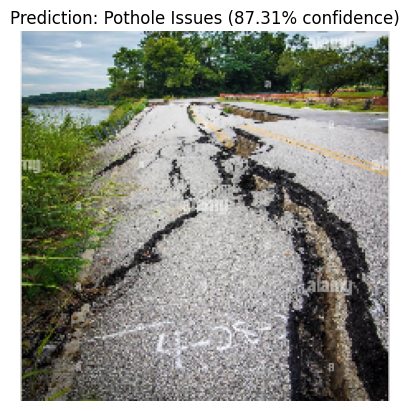

Predicted Issue: Pothole Issues
Confidence: 87.31%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to your saved model (update if you saved with another name)
model_path = "/content/road_damage_model.h5"

# Load the trained model
from tensorflow.keras.models import load_model
model = load_model(model_path)

# Class names (update based on your folders)
class_labels = ['Broken Road Sign Issues', 'Damaged Road Issues', 'Illegal Parking Issues', 'Mixed Issues', 'Pothole Issues']

# === Prediction Function ===
def predict_road_issue(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))  # ResNet50 size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # same normalization used during training

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    # Show result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {class_labels[predicted_class]} ({confidence*100:.2f}% confidence)")
    plt.show()

    print(f"Predicted Issue: {class_labels[predicted_class]}")
    print(f"Confidence: {confidence*100:.2f}%")

# Example usage:
predict_road_issue("/content/DAMAGED ROAD ISSUE.jfif")  # <-- replace with your test image path

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


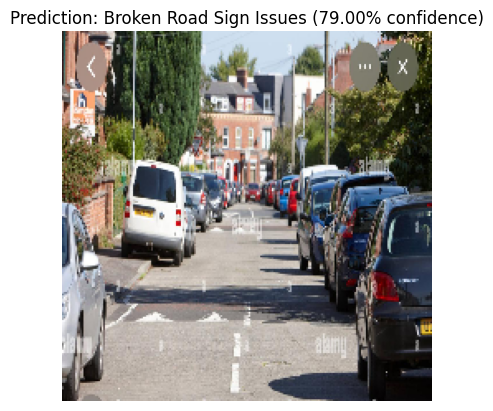

Predicted Issue: Broken Road Sign Issues
Confidence: 79.00%


In [ ]:
predict_road_issue("/content/ILLEGAL PARKING ISSUE.jfif")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


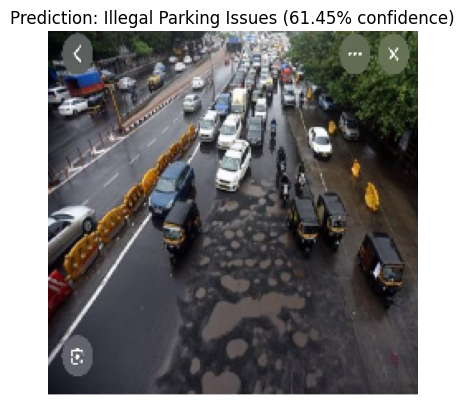

Predicted Issue: Illegal Parking Issues
Confidence: 61.45%


In [ ]:
predict_road_issue("/content/MIXED ISSUE.jfif")